In [3]:
#Import Packages
import xarray as xr
print("Successfully imported xarray")

import matplotlib.pyplot as plt
print("Successfully imported matplotlib")

import numpy as np
print("Successfully imported numpy")

import pandas as pd
print("Successfully imported pandas")

import seaborn as sns
print("Successfully imported seaborn")

import cdsapi
print("Successfully imported cdsapi")

import cartopy.crs as ccrs
print("Successfully imported cartopy.crs")

import cartopy.feature as cfeature
print("Successfully imported cartopy.feature")

Successfully imported xarray
Successfully imported matplotlib
Successfully imported numpy
Successfully imported pandas
Successfully imported seaborn


/Users/shaniabrace/Desktop/Spark/Projects/Mangroves/Suriname Mangrove Project/plots.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Successfully imported cdsapi
Successfully imported cartopy.crs
Successfully imported cartopy.feature


In [4]:
import pandas as pd

df = pd.read_csv("suriname_all_vars_2004_2023.csv")  # adjust filename to match what you downloaded
print(df.columns.tolist())
print(df.head())

['system:index', 'convective_precipitation', 'date', 'surface_solar_radiation_downwards', 'total_cloud_cover', 'total_precipitation', '.geo']
   system:index  convective_precipitation        date  \
0             0                  0.015942  2004-01-01   
1             1                  0.003057  2004-01-02   
2             2                  0.003471  2004-01-03   
3             3                  0.012302  2004-01-04   
4             4                  0.005708  2004-01-05   

   surface_solar_radiation_downwards  total_cloud_cover  total_precipitation  \
0                       1.164286e+07           0.988459             0.018975   
1                       1.808253e+07           0.686220             0.004087   
2                       1.784671e+07           0.432867             0.004840   
3                       1.319494e+07           0.824493             0.014700   
4                       1.684875e+07           0.860476             0.007772   

                                  

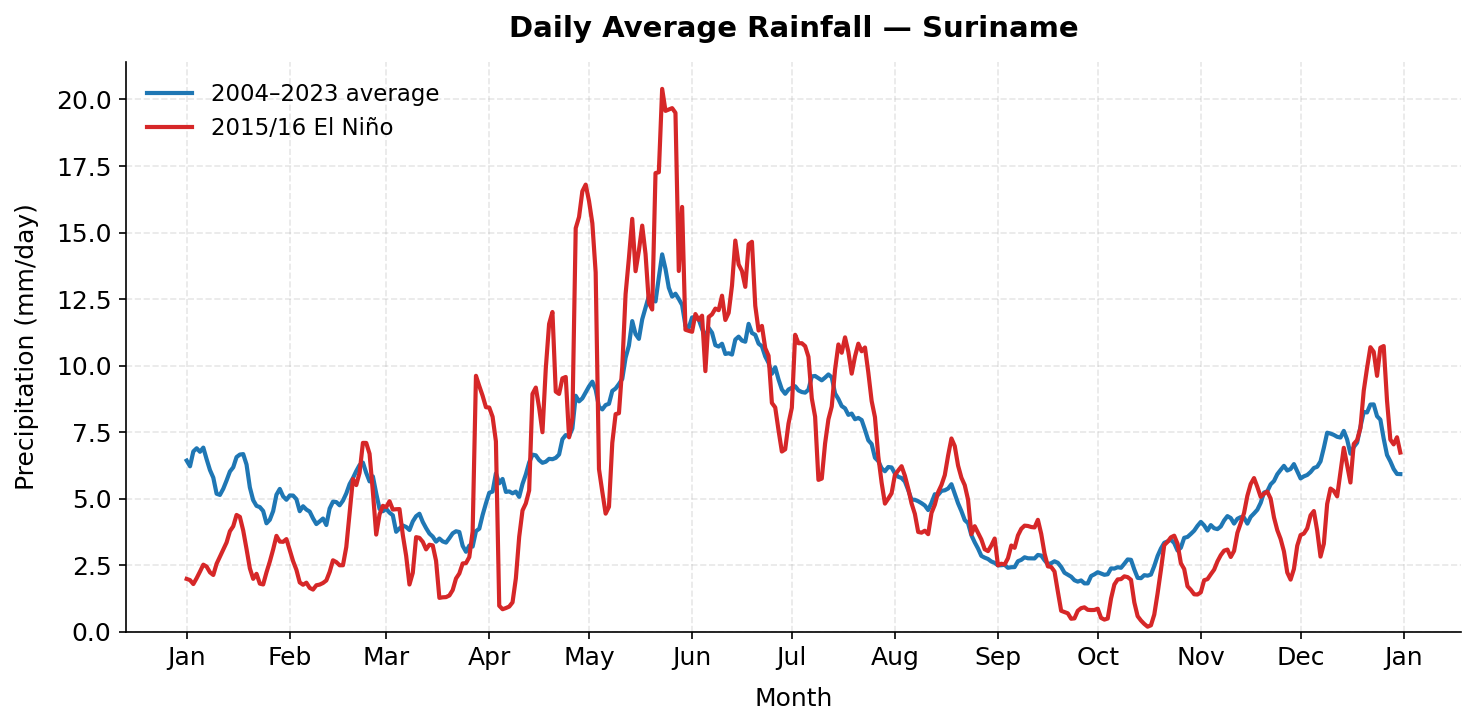

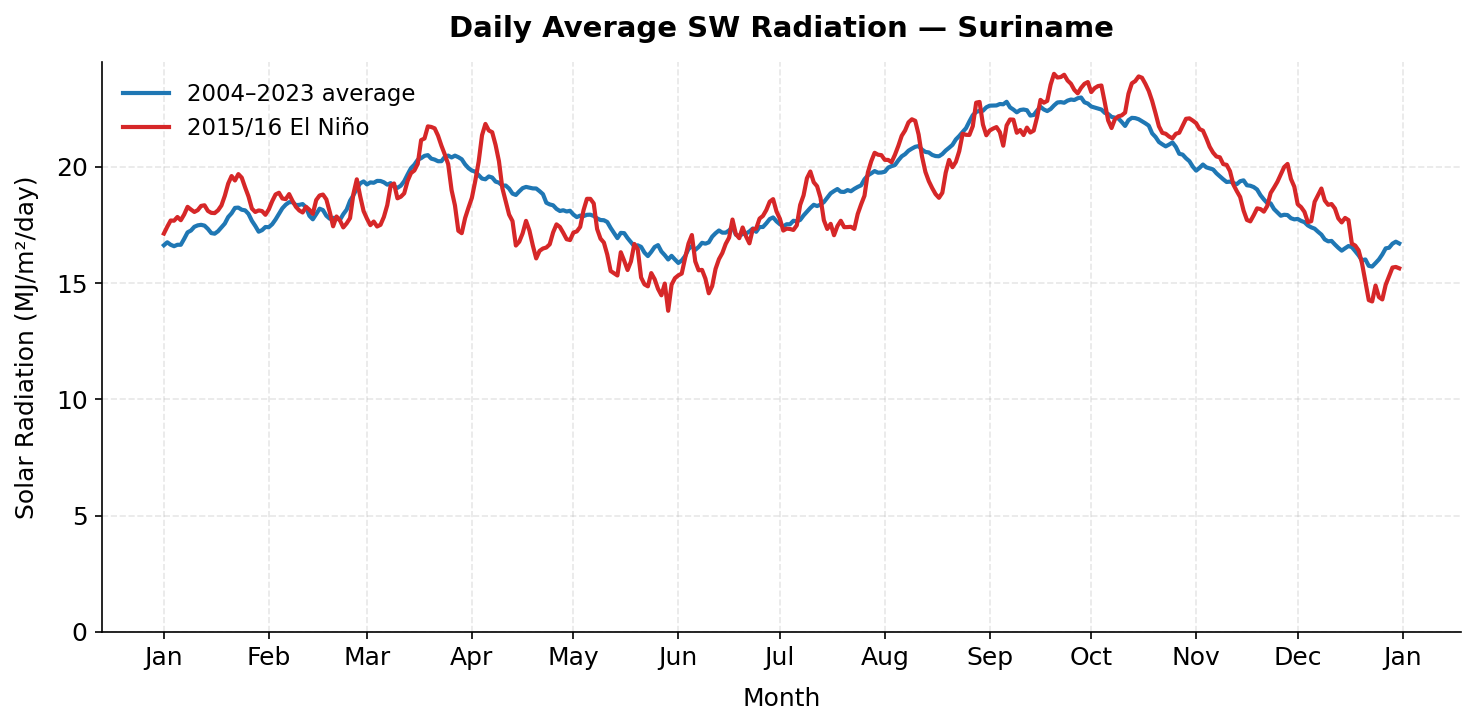

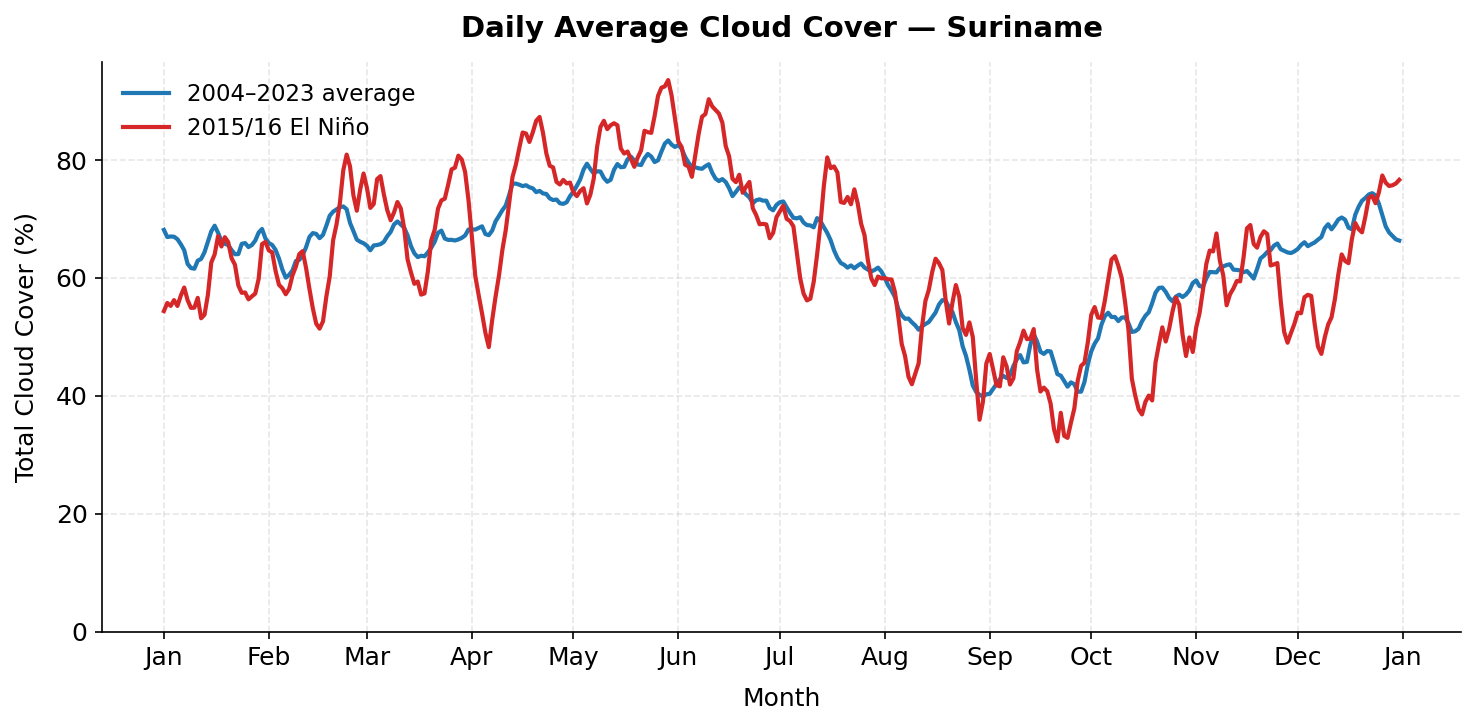

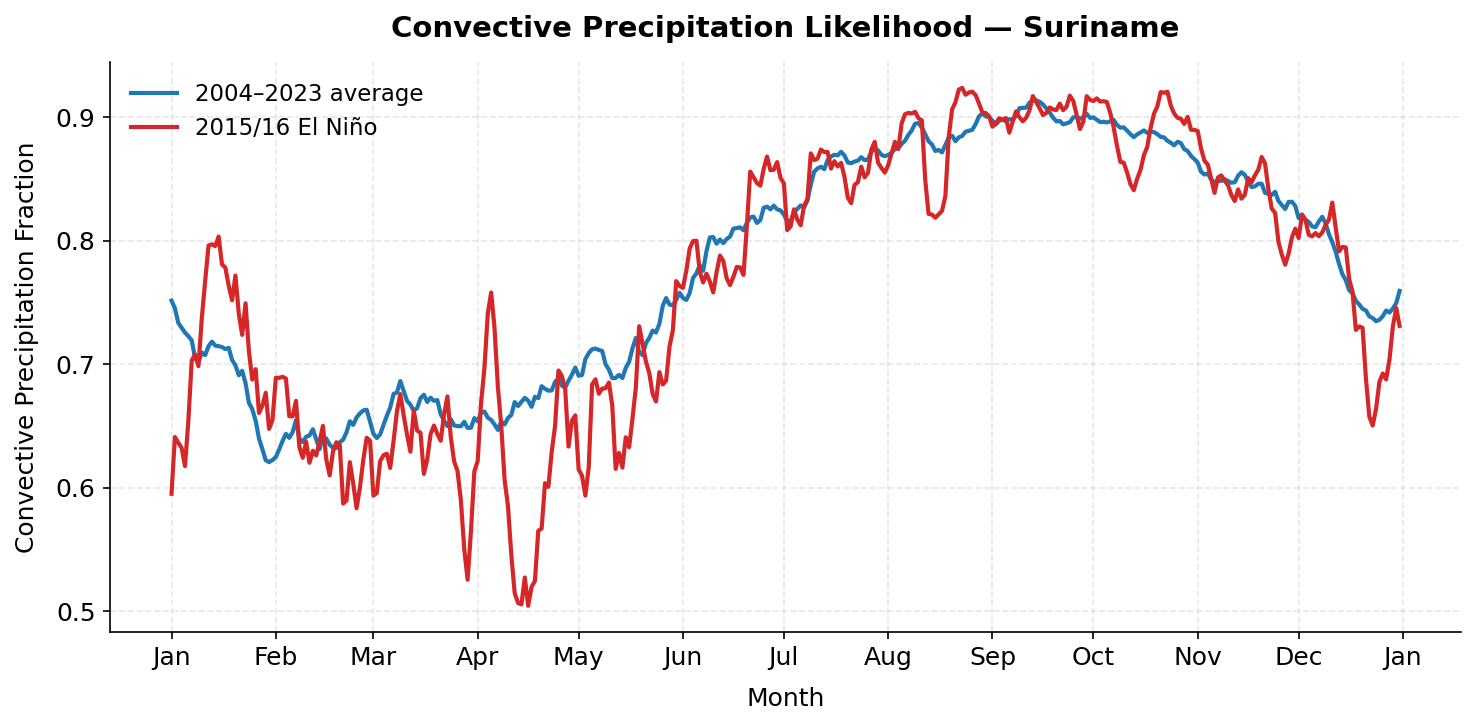

In [5]:
#Loading and Cleaning Data 
df = pd.read_csv("suriname_all_vars_2004_2023.csv")
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['month_day'] = df['date'].dt.strftime('%m-%d')

#Unit Conversion 
df['precip_mm'] = df['total_precipitation'] * 1000
df['convective_precip_mm'] = df['convective_precipitation'] * 1000
df['ssrd_MJ_m2'] = df['surface_solar_radiation_downwards'] / 1e6
df['cloud_cover_pct'] = df['total_cloud_cover'] * 100

# Convective precipitation fraction (guard against divide-by-zero)
df['convective_fraction'] = np.where(
    df['precip_mm'] > 0.01,
    df['convective_precip_mm'] / df['precip_mm'],
    np.nan
)

#Split into climatology (all 20 years) and El Niño (2015+2016)
climatology = df.groupby('month_day').agg({
    'precip_mm': 'mean',
    'ssrd_MJ_m2': 'mean',
    'cloud_cover_pct': 'mean',
    'convective_fraction': 'mean'
}).reset_index()

el_nino = df[df['year'].isin([2015, 2016])].groupby('month_day').agg({
    'precip_mm': 'mean',
    'ssrd_MJ_m2': 'mean',
    'cloud_cover_pct': 'mean',
    'convective_fraction': 'mean'
}).reset_index()

# Sort both by actual calendar order (month_day is a string, so sort via a dummy date)
climatology['sort_key'] = pd.to_datetime('2020-' + climatology['month_day'], format='%Y-%m-%d')
climatology = climatology.sort_values('sort_key')

el_nino['sort_key'] = pd.to_datetime('2020-' + el_nino['month_day'], format='%Y-%m-%d')
el_nino = el_nino.sort_values('sort_key')

#Plot guide
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 150
})

def smooth(series, window=7):
    return series.rolling(window=window, center=True, min_periods=1).mean()

def plot_variable(column, ylabel, title, filename, y_min=None):
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(climatology['sort_key'], smooth(climatology[column]),
            color='#1f77b4', linewidth=2, label='2004–2023 average')
    ax.plot(el_nino['sort_key'], smooth(el_nino[column]),
            color='#d62728', linewidth=2, label='2015/16 El Niño')

    ax.set_xlabel('Month', labelpad=8)
    ax.set_ylabel(ylabel, labelpad=8)
    ax.set_title(title, pad=12)

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if y_min is not None:
        ax.set_ylim(bottom=y_min)

    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()

plot_variable('precip_mm', 'Precipitation (mm/day)',
              'Daily Average Rainfall — Suriname', 'plot_rainfall.png', y_min=0)

plot_variable('ssrd_MJ_m2', 'Solar Radiation (MJ/m²/day)',
              'Daily Average SW Radiation — Suriname', 'plot_solar_radiation.png', y_min=0)

plot_variable('cloud_cover_pct', 'Total Cloud Cover (%)',
              'Daily Average Cloud Cover — Suriname', 'plot_cloud_cover.png', y_min=0)

plot_variable('convective_fraction', 'Convective Precipitation Fraction',
              'Convective Precipitation Likelihood — Suriname', 'plot_convective_fraction.png')

In [6]:
#AM/PM Analysis

import pandas as pd

df_ampm = pd.read_csv("suriname_ampm_2004_2023.csv")  # adjust filename if yours differs
print(df_ampm.columns.tolist())
print(df_ampm.head())

['system:index', 'am_cloud', 'am_convective', 'am_precip', 'am_ssrd', 'date', 'pm_cloud', 'pm_convective', 'pm_precip', 'pm_ssrd', '.geo']
   system:index  am_cloud  am_convective  am_precip       am_ssrd        date  \
0             0  0.991578       0.004436   0.004892  2.971620e+06  2004-01-01   
1             1  0.633948       0.000180   0.000400  4.261892e+06  2004-01-02   
2             2  0.432267       0.000820   0.001153  4.255956e+06  2004-01-03   
3             3  0.845824       0.002370   0.002690  3.428365e+06  2004-01-04   
4             4  0.845793       0.000352   0.000506  4.076612e+06  2004-01-05   

   pm_cloud  pm_convective  pm_precip       pm_ssrd  \
0  0.985751       0.003449   0.004170  6.642179e+06   
1  0.535022       0.000302   0.000465  9.831039e+06   
2  0.409378       0.000294   0.000474  9.912380e+06   
3  0.891075       0.003861   0.004523  7.236606e+06   
4  0.842523       0.000706   0.000962  9.736342e+06   

                                     .geo  

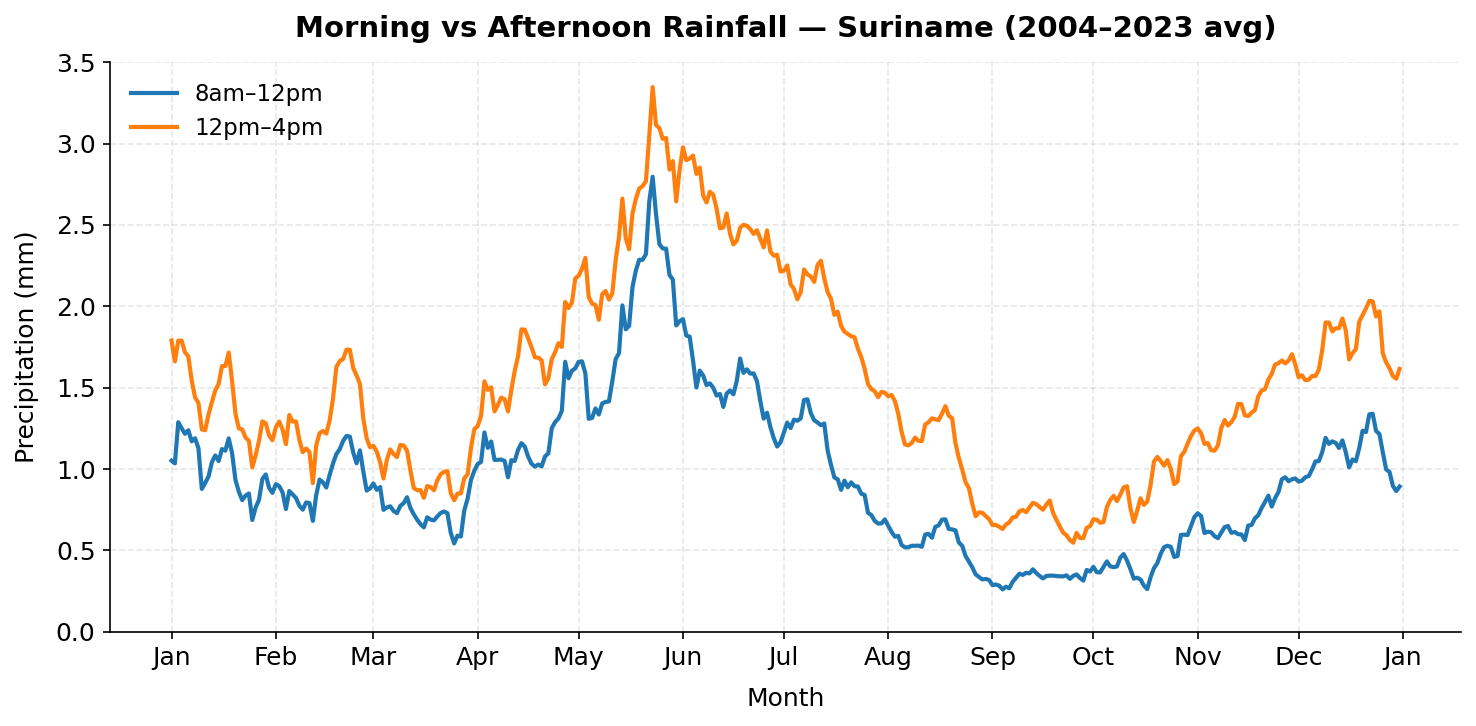

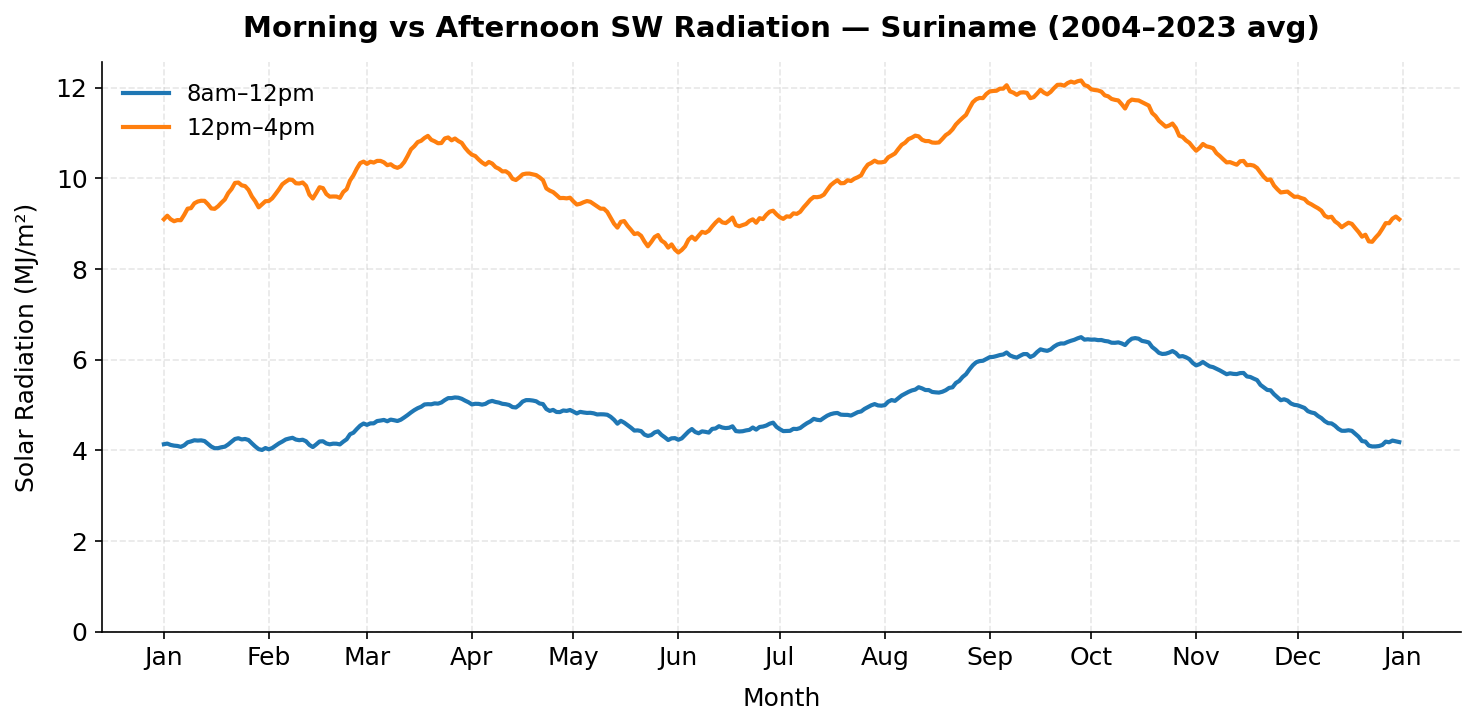

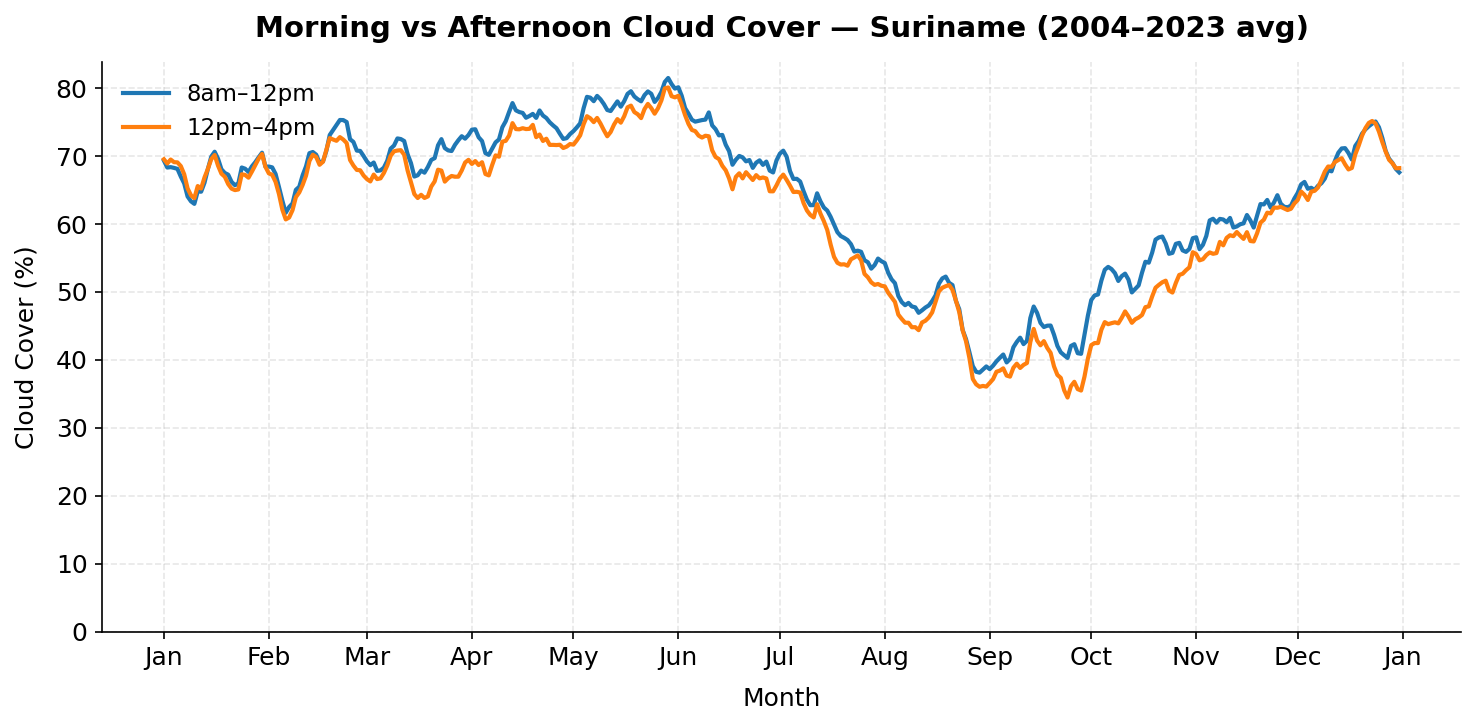

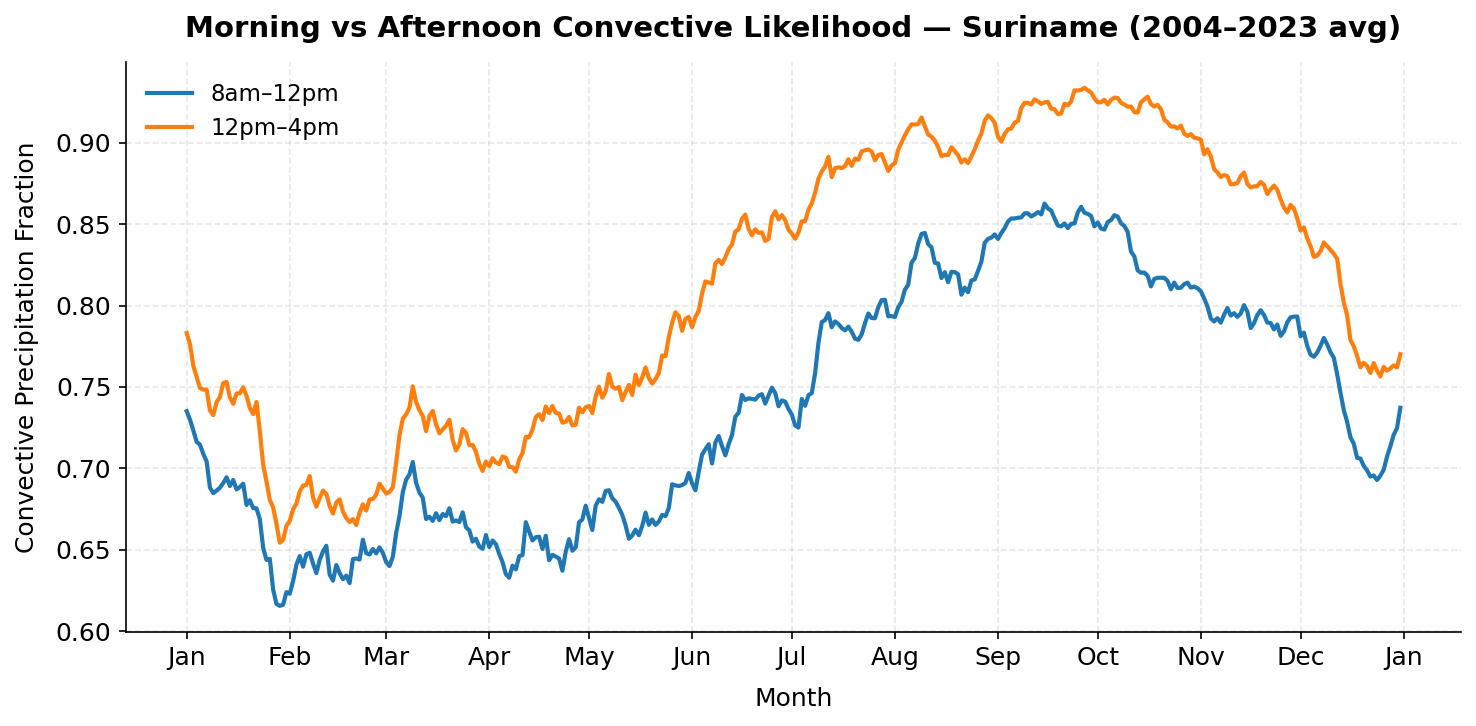

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_ampm['date'] = pd.to_datetime(df_ampm['date'])
df_ampm['year'] = df_ampm['date'].dt.year
df_ampm['month_day'] = df_ampm['date'].dt.strftime('%m-%d')

# --- Unit conversions, same as before, applied to both AM and PM ---
for period in ['am', 'pm']:
    df_ampm[f'{period}_precip_mm'] = df_ampm[f'{period}_precip'] * 1000
    df_ampm[f'{period}_convective_mm'] = df_ampm[f'{period}_convective'] * 1000
    df_ampm[f'{period}_ssrd_MJ_m2'] = df_ampm[f'{period}_ssrd'] / 1e6
    df_ampm[f'{period}_cloud_pct'] = df_ampm[f'{period}_cloud'] * 100
    df_ampm[f'{period}_convective_fraction'] = np.where(
        df_ampm[f'{period}_precip_mm'] > 0.01,
        df_ampm[f'{period}_convective_mm'] / df_ampm[f'{period}_precip_mm'],
        np.nan
    )

# --- 20-year climatology, AM and PM ---
agg_cols = {
    'am_precip_mm': 'mean', 'pm_precip_mm': 'mean',
    'am_ssrd_MJ_m2': 'mean', 'pm_ssrd_MJ_m2': 'mean',
    'am_cloud_pct': 'mean', 'pm_cloud_pct': 'mean',
    'am_convective_fraction': 'mean', 'pm_convective_fraction': 'mean'
}
climatology_ampm = df_ampm.groupby('month_day').agg(agg_cols).reset_index()
climatology_ampm['sort_key'] = pd.to_datetime('2020-' + climatology_ampm['month_day'], format='%Y-%m-%d')
climatology_ampm = climatology_ampm.sort_values('sort_key')

def smooth(series, window=7):
    return series.rolling(window=window, center=True, min_periods=1).mean()

plt.rcParams.update({
    'font.size': 12, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 12, 'legend.fontsize': 11, 'figure.dpi': 150
})

def plot_ampm(am_col, pm_col, ylabel, title, filename, y_min=None):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(climatology_ampm['sort_key'], smooth(climatology_ampm[am_col]),
            color='#1f77b4', linewidth=2, label='8am–12pm')
    ax.plot(climatology_ampm['sort_key'], smooth(climatology_ampm[pm_col]),
            color='#ff7f0e', linewidth=2, label='12pm–4pm')
    ax.set_xlabel('Month', labelpad=8)
    ax.set_ylabel(ylabel, labelpad=8)
    ax.set_title(title, pad=12)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if y_min is not None:
        ax.set_ylim(bottom=y_min)
    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()

plot_ampm('am_precip_mm', 'pm_precip_mm', 'Precipitation (mm)',
          'Morning vs Afternoon Rainfall — Suriname (2004–2023 avg)', 'plot_ampm_rainfall.png', y_min=0)
plot_ampm('am_ssrd_MJ_m2', 'pm_ssrd_MJ_m2', 'Solar Radiation (MJ/m²)',
          'Morning vs Afternoon SW Radiation — Suriname (2004–2023 avg)', 'plot_ampm_radiation.png', y_min=0)
plot_ampm('am_cloud_pct', 'pm_cloud_pct', 'Cloud Cover (%)',
          'Morning vs Afternoon Cloud Cover — Suriname (2004–2023 avg)', 'plot_ampm_cloud.png', y_min=0)
plot_ampm('am_convective_fraction', 'pm_convective_fraction', 'Convective Precipitation Fraction',
          'Morning vs Afternoon Convective Likelihood — Suriname (2004–2023 avg)', 'plot_ampm_convective.png')

['system:index', 'date', 'temperature_2m', '.geo']
   system:index        date  temperature_2m  \
0             0  2004-01-01      298.563650   
1             1  2004-01-02      299.579041   
2             2  2004-01-03      299.262458   
3             3  2004-01-04      298.598012   
4             4  2004-01-05      298.863052   

                                     .geo  
0  {"type":"MultiPoint","coordinates":[]}  
1  {"type":"MultiPoint","coordinates":[]}  
2  {"type":"MultiPoint","coordinates":[]}  
3  {"type":"MultiPoint","coordinates":[]}  
4  {"type":"MultiPoint","coordinates":[]}  


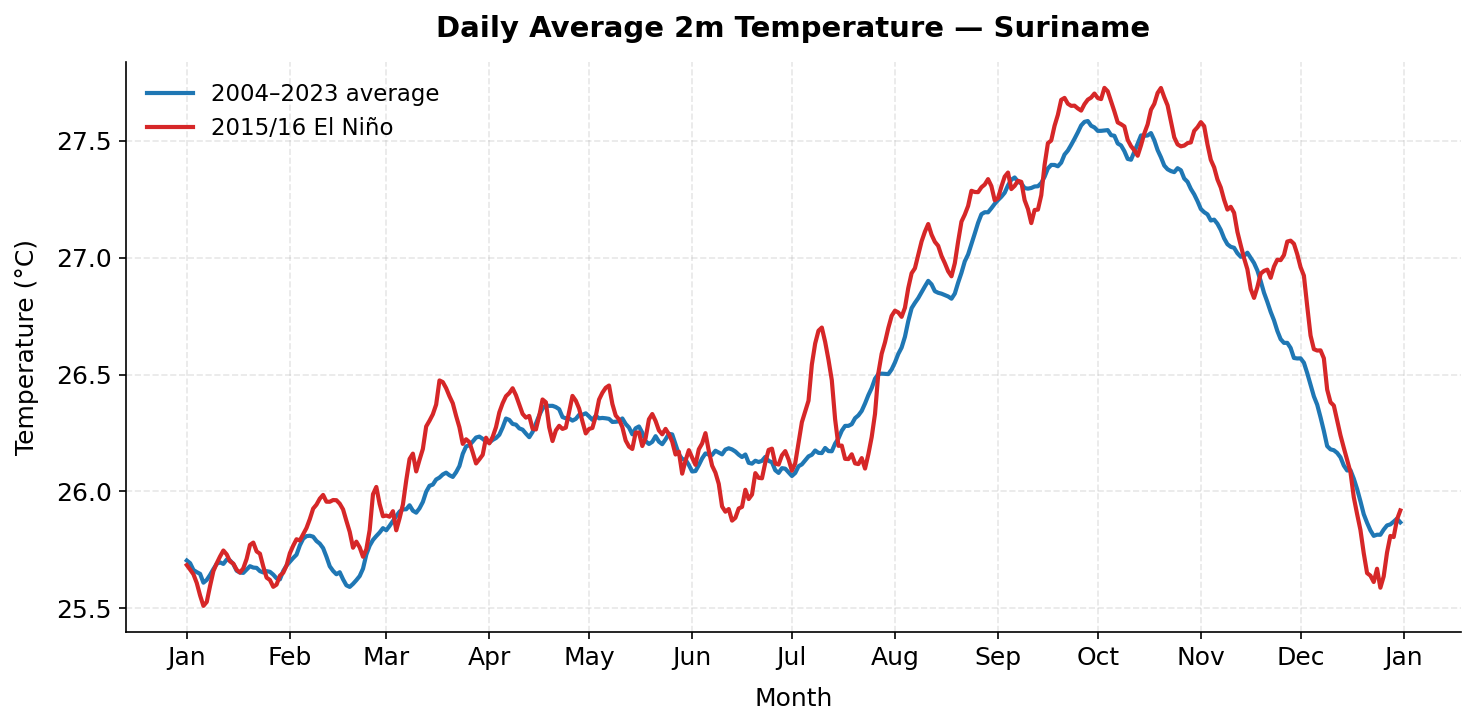

20-year mean temp: 26.4°C
20-year temp range: 25.5°C to 27.6°C


In [8]:
import pandas as pd

df_temp = pd.read_csv("suriname_temp_2004_2023.csv")
print(df_temp.columns.tolist())
print(df_temp.head())

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_temp['date'] = pd.to_datetime(df_temp['date'])
df_temp['year'] = df_temp['date'].dt.year
df_temp['month_day'] = df_temp['date'].dt.strftime('%m-%d')

# Convert Kelvin to Celsius
temp_col = 'temperature_2m'  # adjust if the printed column name differs
df_temp['temp_C'] = df_temp[temp_col] - 273.15

# --- Climatology (all 20 years) and El Niño (2015+2016) ---
climatology_temp = df_temp.groupby('month_day')['temp_C'].mean().reset_index()
el_nino_temp = df_temp[df_temp['year'].isin([2015, 2016])].groupby('month_day')['temp_C'].mean().reset_index()

climatology_temp['sort_key'] = pd.to_datetime('2020-' + climatology_temp['month_day'], format='%Y-%m-%d')
climatology_temp = climatology_temp.sort_values('sort_key')

el_nino_temp['sort_key'] = pd.to_datetime('2020-' + el_nino_temp['month_day'], format='%Y-%m-%d')
el_nino_temp = el_nino_temp.sort_values('sort_key')

def smooth(series, window=7):
    return series.rolling(window=window, center=True, min_periods=1).mean()

plt.rcParams.update({
    'font.size': 12, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 12, 'legend.fontsize': 11, 'figure.dpi': 150
})

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(climatology_temp['sort_key'], smooth(climatology_temp['temp_C']),
        color='#1f77b4', linewidth=2, label='2004–2023 average')
ax.plot(el_nino_temp['sort_key'], smooth(el_nino_temp['temp_C']),
        color='#d62728', linewidth=2, label='2015/16 El Niño')

ax.set_xlabel('Month', labelpad=8)
ax.set_ylabel('Temperature (°C)', labelpad=8)
ax.set_title('Daily Average 2m Temperature — Suriname', pad=12)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.savefig('plot_temperature.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"20-year mean temp: {climatology_temp['temp_C'].mean():.1f}°C")
print(f"20-year temp range: {climatology_temp['temp_C'].min():.1f}°C to {climatology_temp['temp_C'].max():.1f}°C")

In [9]:
annual_total_mm = climatology['precip_mm'].sum()
print(f"20-year average annual precipitation: {annual_total_mm:.0f} mm")

20-year average annual precipitation: 2214 mm
